## Analyse Exploratoire des données (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv('../data/data.csv')
df.head(30)

,age,gender,status,pressurehight,pressurelow,glucose,kcm,troponin,impluse
0,64,1,negative,160,83,160.0,1.800,0.012,66
1,21,1,positive,98,46,296.0,6.750,1.060,94
2,55,1,negative,160,77,270.0,1.990,0.003,64
3,64,1,positive,120,55,270.0,13.870,0.122,70
4,55,1,negative,112,65,300.0,1.080,0.003,64
5,58,0,negative,112,58,87.0,1.830,0.004,61
6,32,0,negative,179,68,102.0,0.710,0.003,40
7,63,1,positive,214,82,87.0,300.000,2.370,60
8,44,0,negative,154,81,135.0,2.350,0.004,60
9,67,1,negative,160,95,100.0,2.840,0.011,61


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1319 non-null   int64  
 1   gender         1319 non-null   int64  
 2   status         1319 non-null   object 
 3   pressurehight  1319 non-null   int64  
 4   pressurelow    1319 non-null   int64  
 5   glucose        1319 non-null   float64
 6   kcm            1319 non-null   float64
 7   troponin       1319 non-null   float64
 8   impluse        1319 non-null   int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [39]:
df.describe()

,age,gender,pressurehight,pressurelow,glucose,kcm,troponin,impluse
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,127.170584,72.269143,146.634344,15.274306,0.360942,78.336619
std,13.647315,0.474027,26.122720,14.033924,74.923045,46.327083,1.154568,51.630270
min,14.000000,0.000000,42.000000,38.000000,35.000000,0.321000,0.001000,20.000000
25%,47.000000,0.000000,110.000000,62.000000,98.000000,1.655000,0.006000,64.000000
50%,58.000000,1.000000,124.000000,72.000000,116.000000,2.850000,0.014000,74.000000
75%,65.000000,1.000000,143.000000,81.000000,169.500000,5.805000,0.085500,85.000000
max,103.000000,1.000000,223.000000,154.000000,541.000000,300.000000,10.300000,1111.000000


In [40]:
df.isnull().sum()

age              0
gender           0
status           0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
impluse          0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df.isnull().sum()


age              0
gender           0
status           0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
impluse          0
dtype: int64

## Visualisation

### Analyse de la Variable Cible (status)

Text(0.5, 1.0, 'Distribution de la variable cible')

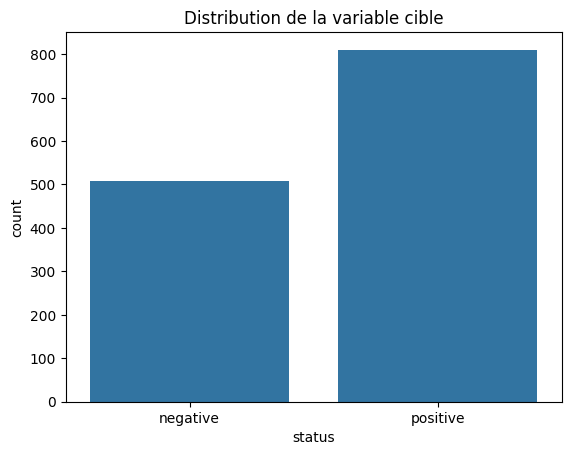

In [43]:
sns.countplot(x='status', data=df);
plt.title("Distribution de la variable cible")

### Analyse des Variables Numériques

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'gender'}>,
        <Axes: title={'center': 'pressurehight'}>],
       [<Axes: title={'center': 'pressurelow'}>,
        <Axes: title={'center': 'glucose'}>,
        <Axes: title={'center': 'kcm'}>],
       [<Axes: title={'center': 'troponin'}>,
        <Axes: title={'center': 'impluse'}>, <Axes: >]], dtype=object)

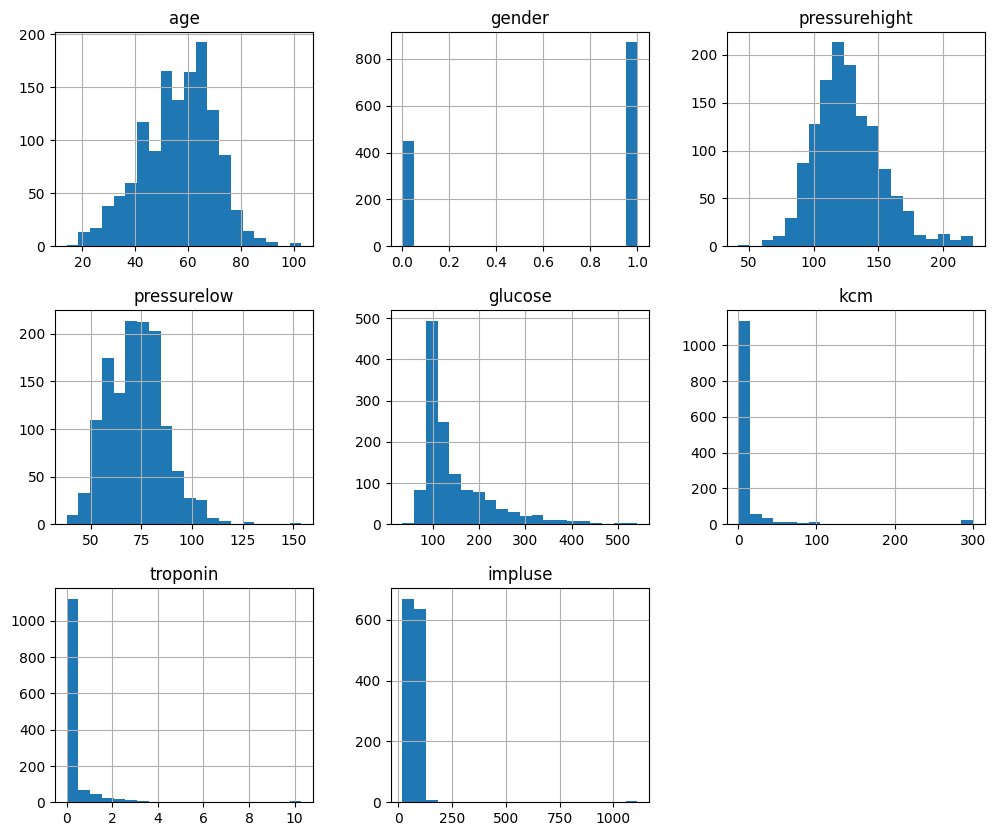

In [44]:
df.hist(figsize=(12, 10), bins=20)


Text(0.5, 1.0, 'Matrice de Corrélation des Variables')

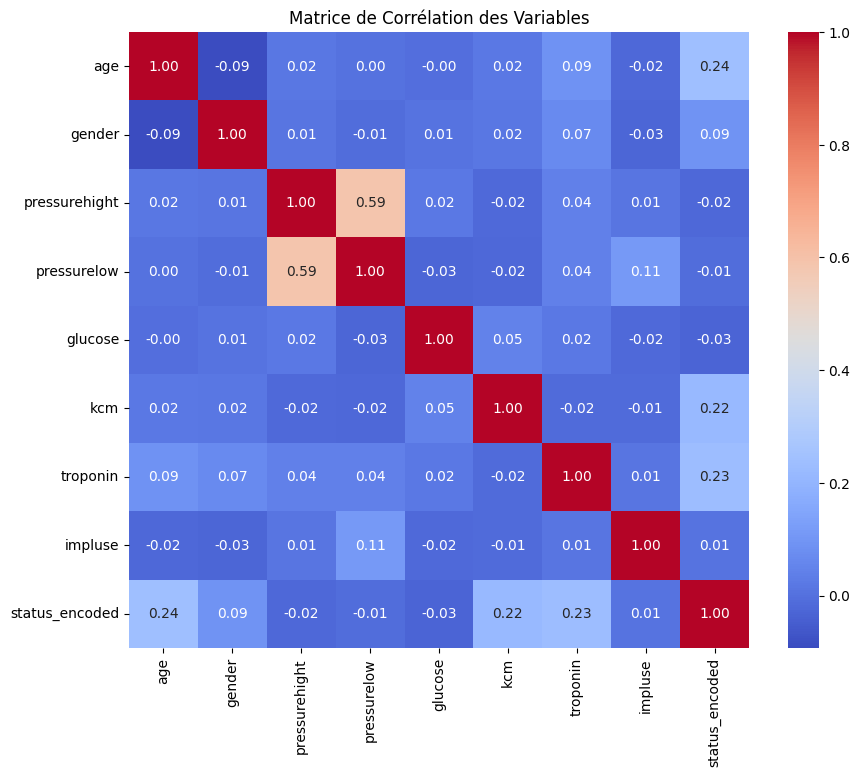

In [64]:
df_corr = df.copy()
df_corr['status_encoded'] = df_corr['status'].map({'positive': 1, 'negative': 0})
correlation_matrix = df_corr.drop('status', axis=1).corr()
plt.figure(figsize=(10, 8)) 
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation des Variables')

La troponin et le kcm montrent la corrélation la plus forte avec le status.

Le dataset est modérément déséquilibré, nous devrons surveiller le F1-Score.

Le StandardScaler est indispensable en raison des différentes échelles des variables.